<a href="https://colab.research.google.com/github/frostd1022/neur_256_spring26/blob/main/Homework_4_Frost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

David Frost

*Intro to Neural Data Analysis*

**3/6/26**

In [2]:
#Importing the relevant modules

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
#Importing data from github repository

url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq = pd.read_csv(url)

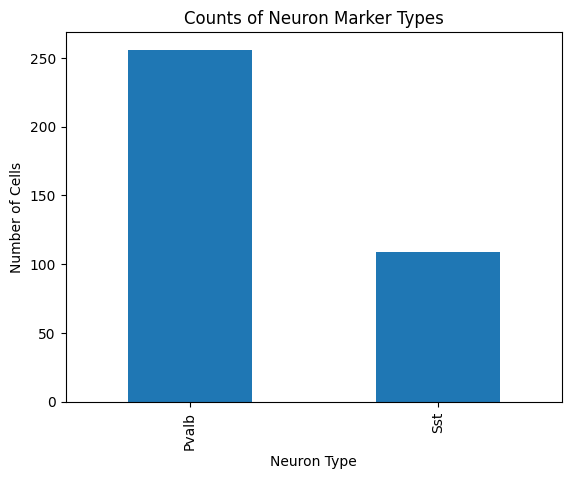

In [4]:
#Using .plot, made a bar graph that displays the value counts from the marker column of patchseq.

patch_seq['Marker'].value_counts().plot(kind='bar')

plt.xlabel('Neuron Type')
plt.ylabel('Number of Cells')
plt.title('Counts of Neuron Marker Types')

plt.show()

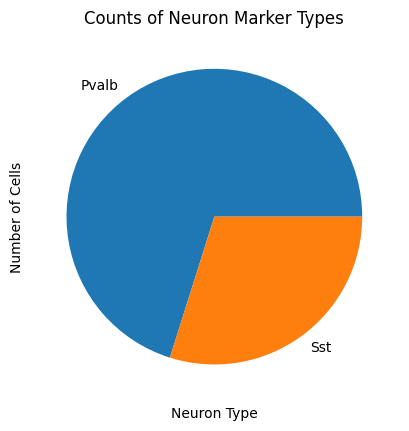

In [5]:
#Made it into a pie chart instead

patch_seq['Marker'].value_counts().plot(kind='pie')

plt.xlabel('Neuron Type')
plt.ylabel('Number of Cells')
plt.title('Counts of Neuron Marker Types')

plt.show()

In [8]:
#Defined patchScatter() and used a for loop to make a scatter plot of the ISI values. Made SST neurons red and Pvalb neurons blue.

def patchScatter():

    for i in range(len(patch_seq)):

        if patch_seq['Marker'][i] == 'Sst':
            plt.scatter(patch_seq['ISI'][i], patch_seq['Fast_Trough'][i], color='red')

        elif patch_seq['Marker'][i] == 'Pvalb':
            plt.scatter(patch_seq['ISI'][i], patch_seq['Fast_Trough'][i], color='blue')

    plt.xlabel('ISI')
    plt.ylabel('Fast Trough')
    plt.title('ISI vs Fast Trough')

    plt.show()

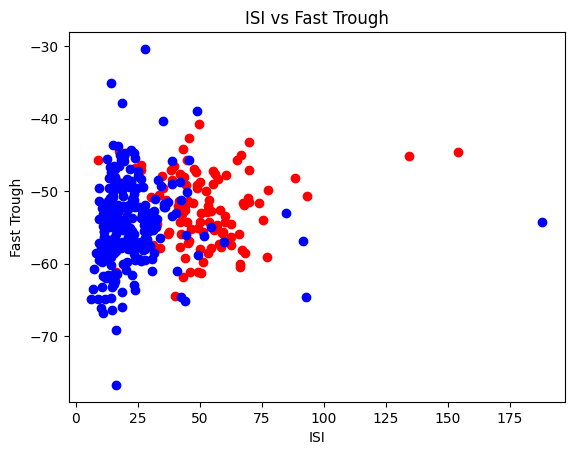

In [15]:
#Calls the code cell above

patchScatter()

In [10]:
#Returns the mean, standard deviation and range of the fast trough column for SST and Pvalb neurons

patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


The difference in means between the SST and Pvalb neurons is about 2 mV. Pvalb has a more negative undershoot following an action potential

In [11]:
#Returned the skewness for Sst and Pvalb neurons

patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


Values that are greater than 0.5 or are less than -0.5 are skewed and if they are in between that range they are normally distributed. Both Pvalb and SST are normally distributed in this case.

In [12]:
#Repeated above for the ISI column of patch_seq

patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


Pvalb and SST are shown to have a skewed spike interval distribution

In [13]:
#Ran a t-test to see if our fast trough and ISI values differ from one another

sst_neurons = patch_seq[patch_seq['Marker'] == 'Sst']
pvalb_neurons = patch_seq[patch_seq['Marker'] == 'Pvalb']

stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

The pvalue is less than .05 so it is statistically significant. The undershoot voltage differs between the two neuron types.

In [14]:
#Repeated step 14 but for ISI and deleted the missing values using .dropna

sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()

stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

The pvalue is greater than .05 so it is statistically insignificant. The undershoot voltage does not differ between neuron types.